In [1]:
!pip -q install datasets

import json
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yaml
from datasets import load_dataset
from google.colab import drive
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,f1_score
from sklearn.model_selection import train_test_split
from torchvision import models
from tqdm.auto import tqdm

os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"

drive.mount("/content/drive")

PROJECT_DIR="/content/drive/MyDrive/ATML-PA1"
os.environ["HF_HOME"]=PROJECT_DIR+"/hf_cache"
for folder in ["shared/splits","task2/configs","task2/results/checkpoints","task2/results/figures"]:
    os.makedirs(PROJECT_DIR+"/"+folder,exist_ok=True)
os.chdir(PROJECT_DIR)

if torch.cuda.is_available():
    DEVICE=torch.device("cuda")
else:
    DEVICE=torch.device("cpu")

torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
torch.use_deterministic_algorithms(True,warn_only=True)

print(torch.__version__,DEVICE,os.getcwd())
if DEVICE.type=="cuda":
    print(torch.cuda.get_device_name(0))

Mounted at /content/drive
2.11.0+cu128 cuda /content/drive/MyDrive/ATML-PA1
Tesla T4


In [2]:
%%writefile task2/configs/task2.yaml
seed: 6304
dataset: pacs
target_domain: sketch #unlabelled during adaptation, labels used only at final evaluation
source_domains: [photo, art_painting, cartoon] #the three labelled domains
val_fraction: 0.2 #stratified 80/20 split within each source domain
resize: 256 #images are resized to 256x256 first
crop: 224 #random crop for training and center crop for evaluation

Overwriting task2/configs/task2.yaml


In [3]:
CONFIG=yaml.safe_load(open("task2/configs/task2.yaml"))
SEED=CONFIG["seed"]
TARGET_DOMAIN=CONFIG["target_domain"]
SOURCE_DOMAINS=CONFIG["source_domains"]
RESIZE=CONFIG["resize"]
CROP=CONFIG["crop"]

dataset=load_dataset("flwrlabs/pacs",split="train")
CLASSES=list(dataset.features["label"].names)
LABELS=np.array(dataset["label"])
DOMAIN_OF=np.array(dataset["domain"])

domain_counts={}
for domain in sorted(set(DOMAIN_OF.tolist())):
    domain_counts[domain]=int((DOMAIN_OF==domain).sum())
print("classes",CLASSES)
print("domains",domain_counts)


def stratified_split(rows,labels,val_fraction,seed):
    #Split one domain's rows so each class keeps its proportion in both halfs.
    random_state=np.random.RandomState(seed)
    rows=np.array(rows)
    train_indices=[]
    val_indices=[]
    for class_index in sorted(set(labels[rows].tolist())):
        members=rows[labels[rows]==class_index]
        shuffled=random_state.permutation(members)
        validation_count=int(round(len(shuffled)*val_fraction))
        val_indices.extend(shuffled[0:validation_count].tolist())
        train_indices.extend(shuffled[validation_count:].tolist())
    return sorted(train_indices),sorted(val_indices)


SPLITS={}
for domain in SOURCE_DOMAINS:
    rows=np.where(DOMAIN_OF==domain)[0]
    train_indices,val_indices=stratified_split(rows,LABELS,CONFIG["val_fraction"],SEED)
    SPLITS[domain]={"train":train_indices,"val":val_indices}
    print(f"{domain:<14}train {len(train_indices):>5}  val {len(val_indices):>5}")
SPLITS[TARGET_DOMAIN]={"all":np.where(DOMAIN_OF==TARGET_DOMAIN)[0].tolist()}
print(f"{TARGET_DOMAIN:<14}unlabelled adaptation set {len(SPLITS[TARGET_DOMAIN]['all'])}")

label_lookup={}
for position in range(len(LABELS)):
    label_lookup[str(position)]=int(LABELS[position])

protocol={"seed":SEED,"classes":CLASSES,"target_domain":TARGET_DOMAIN,
          "source_domains":SOURCE_DOMAINS,"splits":SPLITS,"labels":label_lookup}
json.dump(protocol,open("shared/splits/pacs_sketch_seed6304.json","w"))
print("wrote shared/splits/pacs_sketch_seed6304.json")

IMAGE_BANK=torch.empty((len(dataset),3,RESIZE,RESIZE),dtype=torch.uint8)
for position in tqdm(range(len(dataset))):
    image=dataset[position]["image"].convert("RGB").resize((RESIZE,RESIZE),Image.BICUBIC)
    IMAGE_BANK[position]=torch.from_numpy(np.array(image)).permute(2,0,1)
print("image bank",tuple(IMAGE_BANK.shape),f"{IMAGE_BANK.numel()/1e9:.2f} GB")

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  191MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9991 [00:00<?, ? examples/s]

classes ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']
domains {'art_painting': 2048, 'cartoon': 2344, 'photo': 1670, 'sketch': 3929}
photo         train  1337  val   333
art_painting  train  1638  val   410
cartoon       train  1875  val   469
sketch        unlabelled adaptation set 3929
wrote shared/splits/pacs_sketch_seed6304.json


  0%|          | 0/9991 [00:00<?, ?it/s]

image bank (9991, 3, 256, 256) 1.96 GB


In [4]:
IMAGENET_MEAN=torch.tensor([0.485,0.456,0.406]).view(1,3,1,1).to(DEVICE)
IMAGENET_STD=torch.tensor([0.229,0.224,0.225]).view(1,3,1,1).to(DEVICE)
SOURCE_BATCH_PER_DOMAIN=8
TARGET_BATCH=24
EVAL_BATCH=64


def make_batch(positions,train,generator):
    #Turn rows of the uint8 bank into a normalized float batch on the GPU.
    batch=IMAGE_BANK[positions].to(DEVICE).float()/255.0
    if train==True:
        output=torch.empty((len(positions),3,CROP,CROP),device=DEVICE)
        for row in range(len(positions)):
            top=int(torch.randint(0,RESIZE-CROP+1,(1,),generator=generator).item())
            left=int(torch.randint(0,RESIZE-CROP+1,(1,),generator=generator).item())
            tile=batch[row:row+1,0:,top:top+CROP,left:left+CROP]
            if float(torch.rand(1,generator=generator).item())<0.5:
                tile=torch.flip(tile,dims=[3])
            output[row:row+1]=tile
        batch=output
    else:
        offset=(RESIZE-CROP)//2
        batch=batch[0:,0:,offset:offset+CROP,offset:offset+CROP]
    return (batch-IMAGENET_MEAN)/IMAGENET_STD


def make_sampler(pool,batch_size,seed):
    #Fixed-size index batches from a pool, reshuffling and wrapping when it runs out.
    random_state=np.random.RandomState(seed)
    pool=np.array(pool)
    return {"pool":pool,"batch_size":batch_size,"random_state":random_state,
            "order":random_state.permutation(len(pool)),"cursor":0}


def next_batch(sampler):
    if sampler["cursor"]+sampler["batch_size"]>len(sampler["order"]):
        sampler["order"]=sampler["random_state"].permutation(len(sampler["pool"]))
        sampler["cursor"]=0
    chosen=sampler["order"][sampler["cursor"]:sampler["cursor"]+sampler["batch_size"]]
    sampler["cursor"]=sampler["cursor"]+sampler["batch_size"]
    return sampler["pool"][chosen]

In [5]:
def build_model():
    #ResNet-18 with the ImageNet classifier replaced by a seven-class linear head
    model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc=nn.Linear(512,len(CLASSES))
    return model.to(DEVICE)


def features_and_logits(model,batch):
    #Run torchvision's own forward explicitly so the 512-dimensional feature immediately before the classifier head is available
    hidden=model.conv1(batch)
    hidden=model.bn1(hidden)
    hidden=model.relu(hidden)
    hidden=model.maxpool(hidden)
    hidden=model.layer1(hidden)
    hidden=model.layer2(hidden)
    hidden=model.layer3(hidden)
    hidden=model.layer4(hidden)
    feature=hidden.mean(dim=(2,3))
    return feature,model.fc(feature)


def set_training_mode(model):
    #Put the model in training mode, then put every BatchNorm module back into eval mode.
    model.train()
    for module in model.modules():
        if isinstance(module,nn.BatchNorm2d)==True:
            module.eval()


def reverse_gradient(input_tensor,strength):
    return (1.0+strength)*input_tensor.detach()-strength*input_tensor


def unit_length(rows):
    """Scale every row to length one before it reaches the domain discriminator.
    Without this DANN diverged: the backbone can raise the reversed domain loss simply by making the
    feature longer, and with BatchNorm statistics frozen nothing in the network limits that length.
    With clipping alone the pre-clip gradient norm reached 1.2e7 and the class loss 6504 (saved in
    task2_results_before_unit_length.json). On unit-length rows only the direction of the feature
    reaches the discriminator, so length is no longer a way to win.
    The classifier head still receives the raw feature, so the class loss is unchanged."""
    return rows/rows.norm(dim=1,keepdim=True).clamp_min(1e-6)


def build_discriminator(input_width):
    """256-unit hidden layer, ReLU, dropout 0.5, two-class output. DANN and CDAN use the same shape;
    only the input width differs, 512 for the raw feature and 3584 for the outer product."""
    return nn.Sequential(nn.Linear(input_width,256),nn.ReLU(),nn.Dropout(0.5),nn.Linear(256,2)).to(DEVICE)

In [6]:
def multi_kernel_mmd(source_feature,target_feature):
    #Squared maximum mean discrepancy with a sum of three RBF kernels.
    combined=torch.cat([source_feature,target_feature],dim=0)
    squared=torch.cdist(combined,combined,p=2.0)**2
    upper=torch.triu_indices(len(combined),len(combined),offset=1)
    median=squared[upper[0],upper[1]].detach().median()
    kernel=torch.zeros_like(squared)
    for multiple in [0.5,1.0,2.0]:
        kernel=kernel+torch.exp(-squared/(multiple*median+1e-8))
    source_count=len(source_feature)
    target_count=len(target_feature)
    source_block=kernel[0:source_count,0:source_count]
    target_block=kernel[source_count:,source_count:]
    cross_block=kernel[0:source_count,source_count:]
    source_mean=(source_block.sum()-source_block.diag().sum())/(source_count*(source_count-1))
    target_mean=(target_block.sum()-target_block.diag().sum())/(target_count*(target_count-1))
    return source_mean+target_mean-2.0*cross_block.mean()


def conditional_feature(feature,probabilities):
    #the outer product of the 512-dimensional feature with the seven-way probability vector/
    #flattened to 3584 dimensions
    outer=torch.bmm(feature.unsqueeze(2),probabilities.unsqueeze(1))
    return outer.view(len(feature),-1)

In [7]:
MAX_EPOCHS=30
LEARNING_RATE=1e-4
WEIGHT_DECAY=1e-4
PATIENCE=5


def evaluate(model,positions):
    #accuracy, macro-F1 and the raw predictions on a fixed set of rows, always with the centr crop and the model in eval mode.
    model.eval()
    positions=np.array(positions)
    predictions=[]
    with torch.no_grad():
        for start in range(0,len(positions),EVAL_BATCH):
            chunk=positions[start:start+EVAL_BATCH]
            _,logits=features_and_logits(model,make_batch(chunk,False,None))
            predictions.append(logits.argmax(1).cpu())
    predictions=torch.cat(predictions).numpy()
    truth=LABELS[positions]
    return float((predictions==truth).mean()),float(f1_score(truth,predictions,average="macro")),predictions


def train_method(method,lambda_mmd=1.0,max_strength=1.0):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    generator=torch.Generator().manual_seed(SEED)

    model=build_model()
    parameters=list(model.parameters())
    discriminator=None
    if method=="dann":
        discriminator=build_discriminator(512)
        parameters=parameters+list(discriminator.parameters())
    elif method=="cdan":
        discriminator=build_discriminator(512*len(CLASSES))
        parameters=parameters+list(discriminator.parameters())
    optimizer=torch.optim.AdamW(parameters,lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    criterion=nn.CrossEntropyLoss()

    source_samplers=[]
    for offset,domain in enumerate(SOURCE_DOMAINS):
        source_samplers.append(make_sampler(SPLITS[domain]["train"],SOURCE_BATCH_PER_DOMAIN,SEED+offset))
    target_sampler=make_sampler(SPLITS[TARGET_DOMAIN]["all"],TARGET_BATCH,SEED)

    source_train_total=0
    for domain in SOURCE_DOMAINS:
        source_train_total=source_train_total+len(SPLITS[domain]["train"])
    updates_per_epoch=math.ceil(source_train_total/(SOURCE_BATCH_PER_DOMAIN*len(SOURCE_DOMAINS)))
    domain_targets=torch.cat([torch.zeros(SOURCE_BATCH_PER_DOMAIN*len(SOURCE_DOMAINS),dtype=torch.long),
                              torch.ones(TARGET_BATCH,dtype=torch.long)]).to(DEVICE)

    history=[]
    best_macro_f1=-1.0
    best_state=None
    epochs_without_improvement=0
    for epoch in range(MAX_EPOCHS):
        classification_sum=0.0
        alignment_sum=0.0
        gradient_norm_sum=0.0
        feature_norm_sum=0.0
        for update in range(updates_per_epoch):
            set_training_mode(model)
            if discriminator is not None:
                discriminator.train()

            source_positions=[]
            for sampler in source_samplers:
                source_positions.extend(next_batch(sampler).tolist())
            source_positions=np.array(source_positions)
            source_feature,source_logits=features_and_logits(model,make_batch(source_positions,True,generator))
            classification_loss=criterion(source_logits,torch.tensor(LABELS[source_positions],device=DEVICE))

            alignment_loss=torch.zeros((),device=DEVICE)
            if method!="source_only":
                target_positions=next_batch(target_sampler)
                target_feature,target_logits=features_and_logits(model,make_batch(target_positions,True,generator))
                progress=(epoch*updates_per_epoch+update)/(MAX_EPOCHS*updates_per_epoch)
                strength=max_strength*(2.0/(1.0+math.exp(-10.0*progress))-1.0)
                if method=="dan":
                    alignment_loss=lambda_mmd*multi_kernel_mmd(source_feature,target_feature)
                elif method=="dann":
                    combined=torch.cat([source_feature,target_feature],dim=0)
                    alignment_loss=criterion(discriminator(reverse_gradient(unit_length(combined),strength)),domain_targets)
                elif method=="cdan":
                    combined_feature=torch.cat([source_feature,target_feature],dim=0)
                    combined_logits=torch.cat([source_logits,target_logits],dim=0)
                    conditioned=conditional_feature(combined_feature,torch.softmax(combined_logits,dim=1))
                    alignment_loss=criterion(discriminator(reverse_gradient(unit_length(conditioned),strength)),domain_targets)

            optimizer.zero_grad()
            (classification_loss+alignment_loss).backward()
            #clipped to a global norm of 1, applied identically to every method so the comparison
            #stays controlled and the returned value is the norm before clipping
            gradient_norm=torch.nn.utils.clip_grad_norm_(parameters,1.0)
            optimizer.step()
            classification_sum=classification_sum+float(classification_loss.detach())
            alignment_sum=alignment_sum+float(alignment_loss.detach())
            gradient_norm_sum=gradient_norm_sum+float(gradient_norm)
            feature_norm_sum=feature_norm_sum+float(source_feature.detach().norm(dim=1).mean())

        per_domain={}
        macro_f1_values=[]
        for domain in SOURCE_DOMAINS:
            accuracy,macro_f1,_=evaluate(model,SPLITS[domain]["val"])
            per_domain[domain]={"accuracy":accuracy,"macro_f1":macro_f1}
            macro_f1_values.append(macro_f1)
        mean_macro_f1=float(np.mean(macro_f1_values))
        history.append({"epoch":epoch+1,"classification_loss":classification_sum/updates_per_epoch,
                        "alignment_loss":alignment_sum/updates_per_epoch,
                        "gradient_norm":gradient_norm_sum/updates_per_epoch,
                        "feature_norm":feature_norm_sum/updates_per_epoch,
                        "mean_source_val_macro_f1":mean_macro_f1,"per_domain":per_domain})
        print(f"{method} epoch {epoch+1:>2}  cls {classification_sum/updates_per_epoch:.4f}  "
              f"align {alignment_sum/updates_per_epoch:.4f}  "
              f"gnorm {gradient_norm_sum/updates_per_epoch:.3f}  "
              f"fnorm {feature_norm_sum/updates_per_epoch:.1f}  "
              f"mean source-val macro-F1 {mean_macro_f1:.4f}")

        if mean_macro_f1>best_macro_f1:
            best_macro_f1=mean_macro_f1
            best_state={}
            for key,value in model.state_dict().items():
                best_state[key]=value.clone()
            epochs_without_improvement=0
        else:
            epochs_without_improvement=epochs_without_improvement+1
            if epochs_without_improvement>=PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model,history,best_macro_f1

In [8]:
import shutil

MODELS={}
HISTORIES={}
PREVIOUS=None
if os.path.exists("task2/results/task2_results.json")==True:
    #the run before the discriminator fix is kept as evidence of the divergence it caused
    if os.path.exists("task2/results/task2_results_before_unit_length.json")==False:
        shutil.copy("task2/results/task2_results.json","task2/results/task2_results_before_unit_length.json")
    PREVIOUS=json.load(open("task2/results/task2_results_before_unit_length.json"))


def train_or_load(method):
    """source_only and dan do not use the discriminator, so the fix does not change them. Loading the saved
    checkpoints keeps source_only.pt identical, which task 3 reuses as its ERM baseline. On a fresh runtime
    with no checkpoints everything is trained from scratch."""
    path=f"task2/results/checkpoints/{method}.pt"
    if os.path.exists(path)==True and PREVIOUS is not None:
        model=build_model()
        model.load_state_dict(torch.load(path,map_location=DEVICE,weights_only=True))
        model.eval()
        print(f"{method}: loaded the saved checkpoint")
        return model,PREVIOUS["histories"][method]
    else:
        model,history,best=train_method(method)
        torch.save(model.state_dict(),path)
        print(f"{method} best mean source-val macro-F1 {best:.4f}")
        return model,history


MODELS["source_only"],HISTORIES["source_only"]=train_or_load("source_only")
MODELS["dan"],HISTORIES["dan"]=train_or_load("dan")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 87.2MB/s]


source_only: loaded the saved checkpoint
dan: loaded the saved checkpoint


In [9]:
for method in ["dann","cdan"]:
    MODELS[method],HISTORIES[method],best=train_method(method)
    torch.save(MODELS[method].state_dict(),f"task2/results/checkpoints/{method}.pt")
    print(f"{method} best mean source-val macro-F1 {best:.4f}")


dann epoch  1  cls 0.5336  align 0.6389  gnorm 13.345  fnorm 52.8  mean source-val macro-F1 0.8919
dann epoch  2  cls 0.2674  align 0.7292  gnorm 10.648  fnorm 59.0  mean source-val macro-F1 0.9171
dann epoch  3  cls 0.1971  align 0.6985  gnorm 9.799  fnorm 66.8  mean source-val macro-F1 0.8961
dann epoch  4  cls 0.1656  align 0.6912  gnorm 10.099  fnorm 73.2  mean source-val macro-F1 0.9161
dann epoch  5  cls 0.1355  align 0.6999  gnorm 9.522  fnorm 82.2  mean source-val macro-F1 0.8938
dann epoch  6  cls 0.1226  align 0.6975  gnorm 8.389  fnorm 84.8  mean source-val macro-F1 0.9200
dann epoch  7  cls 0.1149  align 0.7013  gnorm 9.246  fnorm 94.5  mean source-val macro-F1 0.9059
dann epoch  8  cls 0.0869  align 0.7004  gnorm 7.905  fnorm 111.4  mean source-val macro-F1 0.9137
dann epoch  9  cls 0.0976  align 0.7024  gnorm 8.646  fnorm 115.8  mean source-val macro-F1 0.9316
dann epoch 10  cls 0.0716  align 0.6996  gnorm 7.173  fnorm 113.7  mean source-val macro-F1 0.9157
dann epoch 11 

In [10]:
def domain_separability(model):
    #Freeze the backbone and take equal numbers of source-validation and target features and training a balanced logistic regression to say which domain a feature came from.
    source_positions=[]
    for domain in SOURCE_DOMAINS:
        source_positions.extend(SPLITS[domain]["val"])
    source_positions=np.array(source_positions)
    target_positions=np.array(SPLITS[TARGET_DOMAIN]["all"])
    count=min(len(source_positions),len(target_positions))
    random_state=np.random.RandomState(SEED)
    source_positions=random_state.permutation(source_positions)[0:count]
    target_positions=random_state.permutation(target_positions)[0:count]

    model.eval()
    collected=[]
    for positions in [source_positions,target_positions]:
        chunks=[]
        with torch.no_grad():
            for start in range(0,len(positions),EVAL_BATCH):
                feature,_=features_and_logits(model,make_batch(positions[start:start+EVAL_BATCH],False,None))
                chunks.append(feature.cpu())
        collected.append(torch.cat(chunks).numpy())
    features=np.concatenate(collected)
    domain_labels=np.concatenate([np.zeros(count),np.ones(count)])

    train_x,test_x,train_y,test_y=train_test_split(features,domain_labels,test_size=0.3,
                                                   random_state=SEED,stratify=domain_labels)
    classifier=LogisticRegression(C=1.0,class_weight="balanced",max_iter=10000)
    classifier.fit(train_x,train_y)
    return float(classifier.score(test_x,test_y))


RESULTS={}
for method in ["source_only","dan","dann","cdan"]:
    row={"per_domain":{}}
    accuracies=[]
    macro_f1_values=[]
    for domain in SOURCE_DOMAINS:
        accuracy,macro_f1,_=evaluate(MODELS[method],SPLITS[domain]["val"])
        row["per_domain"][domain]={"accuracy":accuracy,"macro_f1":macro_f1}
        accuracies.append(accuracy)
        macro_f1_values.append(macro_f1)
    row["mean_source_accuracy"]=float(np.mean(accuracies))
    row["mean_source_macro_f1"]=float(np.mean(macro_f1_values))
    target_accuracy,target_macro_f1,target_predictions=evaluate(MODELS[method],SPLITS[TARGET_DOMAIN]["all"])
    row["target_accuracy"]=target_accuracy
    row["target_macro_f1"]=target_macro_f1
    row["target_predictions"]=target_predictions.tolist()
    row["domain_separability"]=domain_separability(MODELS[method])
    RESULTS[method]=row

header=f"{'method':<13}"
for domain in SOURCE_DOMAINS:
    header=header+f"{domain[0:8]:>10}"
header=header+f"{'mean acc':>10}{'mean F1':>9}{'tgt acc':>9}{'tgt F1':>8}{'change':>9}{'sep':>7}"
print(header)
for method in RESULTS:
    row=RESULTS[method]
    line=f"{method:<13}"
    for domain in SOURCE_DOMAINS:
        line=line+f"{row['per_domain'][domain]['accuracy']:>10.4f}"
    change=row["target_accuracy"]-RESULTS["source_only"]["target_accuracy"]
    line=line+f"{row['mean_source_accuracy']:>10.4f}{row['mean_source_macro_f1']:>9.4f}"
    line=line+f"{row['target_accuracy']:>9.4f}{row['target_macro_f1']:>8.4f}{change:>+9.4f}{row['domain_separability']:>7.3f}"
    print(line)

method            photo  art_pain   cartoon  mean acc  mean F1  tgt acc  tgt F1   change    sep
source_only      0.9700    0.9000    0.8891    0.9197   0.9193   0.5849  0.5796  +0.0000  1.000
dan              0.9610    0.9268    0.9360    0.9413   0.9369   0.6243  0.5613  +0.0395  0.853
dann             0.9489    0.9195    0.9488    0.9391   0.9351   0.0672  0.0735  -0.5177  0.999
cdan             0.9640    0.9049    0.9232    0.9307   0.9302   0.5213  0.5131  -0.0636  0.999


In [11]:
target_positions=np.array(SPLITS[TARGET_DOMAIN]["all"])
target_truth=LABELS[target_positions]

per_class={}
for method in RESULTS:
    predictions=np.array(RESULTS[method]["target_predictions"])
    per_class[method]={}
    for class_index in range(len(CLASSES)):
        mask=target_truth==class_index
        per_class[method][CLASSES[class_index]]=float((predictions[mask]==class_index).mean())

header=f"{'class':<10}{'support':>8}"
for method in RESULTS:
    header=header+f"{method:>14}"
header=header+f"{'best change':>13}"
print(header)
for class_index in range(len(CLASSES)):
    class_name=CLASSES[class_index]
    support=int((target_truth==class_index).sum())
    line=f"{class_name:<10}{support:>8}"
    best_change=-2.0
    for method in RESULTS:
        line=line+f"{per_class[method][class_name]:>14.3f}"
        change=per_class[method][class_name]-per_class["source_only"][class_name]
        if change>best_change:
            best_change=change
    line=line+f"{best_change:>+13.3f}"
    print(line)

for method in ["dan","dann","cdan"]:
    worst_name=CLASSES[0]
    worst_change=2.0
    best_name=CLASSES[0]
    best_change=-2.0
    for class_name in CLASSES:
        change=per_class[method][class_name]-per_class["source_only"][class_name]
        if change<worst_change:
            worst_change=change
            worst_name=class_name
        if change>best_change:
            best_change=change
            best_name=class_name
    print(f"\n{method}: worst {worst_name} {worst_change:+.3f}, best {best_name} {best_change:+.3f}")
    matrix=confusion_matrix(target_truth,np.array(RESULTS[method]["target_predictions"]),labels=range(len(CLASSES)))
    for class_name in [worst_name,best_name]:
        class_index=CLASSES.index(class_name)
        row=matrix[class_index].copy()
        row[class_index]=0
        confused=int(row.argmax())
        if row[confused]==0:
            print(f"  {class_name} -> no errors")
        else:
            print(f"  {class_name} -> mostly confused with {CLASSES[confused]} ({row[confused]} of {int(matrix[class_index].sum())})")

class      support   source_only           dan          dann          cdan  best change
dog            772         0.228         0.339         0.000         0.737       +0.509
elephant       740         0.989         0.727         0.000         0.024       +0.000
giraffe        753         0.548         0.636         0.027         0.603       +0.088
guitar         608         0.666         0.875         0.123         0.660       +0.209
horse          816         0.580         0.665         0.002         0.589       +0.086
house           80         0.500         1.000         0.087         0.500       +0.500
person         160         0.369         0.119         1.000         0.531       +0.631

dan: worst elephant -0.262, best house +0.500
  elephant -> mostly confused with person (103 of 740)
  house -> no errors

dann: worst elephant -0.989, best person +0.631
  elephant -> mostly confused with person (740 of 740)
  person -> no errors

cdan: worst elephant -0.965, best dog +0.509
 

In [12]:
LAMBDA_VALUES=[0.1,1.0,10.0]
STUDY={}
STUDY[1.0]={"target_accuracy":RESULTS["dan"]["target_accuracy"],
            "mean_source_accuracy":RESULTS["dan"]["mean_source_accuracy"],
            "domain_separability":RESULTS["dan"]["domain_separability"]}

for value in [0.1,10.0]:
    if PREVIOUS is not None and str(value) in PREVIOUS["lambda_study"]:
        #DAN has no discriminator, so these runs are unaffected by the fix and are reused
        STUDY[value]=PREVIOUS["lambda_study"][str(value)]
        HISTORIES[f"dan_lambda_{value}"]=PREVIOUS["histories"][f"dan_lambda_{value}"]
    else:
        model,history,best=train_method("dan",lambda_mmd=value)
        accuracies=[]
        for domain in SOURCE_DOMAINS:
            accuracy,macro_f1,_=evaluate(model,SPLITS[domain]["val"])
            accuracies.append(accuracy)
        target_accuracy,target_macro_f1,_=evaluate(model,SPLITS[TARGET_DOMAIN]["all"])
        STUDY[value]={"target_accuracy":target_accuracy,"mean_source_accuracy":float(np.mean(accuracies)),
                      "domain_separability":domain_separability(model)}
        HISTORIES[f"dan_lambda_{value}"]=history
    print(f"lambda {value}: mean source {STUDY[value]['mean_source_accuracy']:.4f}  "
          f"target {STUDY[value]['target_accuracy']:.4f}  separability {STUDY[value]['domain_separability']:.3f}")

print(f"\n{'lambda_MMD':<12}{'mean source acc':>17}{'target acc':>12}{'separability':>14}")
for value in LAMBDA_VALUES:
    row=STUDY[value]
    print(f"{value:<12}{row['mean_source_accuracy']:>17.4f}{row['target_accuracy']:>12.4f}{row['domain_separability']:>14.3f}")


lambda 0.1: mean source 0.9402  target 0.7093  separability 0.942
lambda 10.0: mean source 0.9001  target 0.5946  separability 0.897

lambda_MMD    mean source acc  target acc  separability
0.1                    0.9402      0.7093         0.942
1.0                    0.9413      0.6243         0.853
10.0                   0.9001      0.5946         0.897


In [13]:
control_model,control_history,control_best=train_method("dann",max_strength=0.0)
HISTORIES["dann_strength_0.0"]=control_history
print(f"dann with reversal strength 0 (discriminator trains, backbone gets no adversarial gradient): "
      f"best mean source-val macro-F1 {control_best:.4f}, epochs run {len(control_history)}")


dann epoch  1  cls 0.5375  align 0.6015  gnorm 13.266  fnorm 52.9  mean source-val macro-F1 0.8862
dann epoch  2  cls 0.2565  align 0.3873  gnorm 10.988  fnorm 60.2  mean source-val macro-F1 0.9124
dann epoch  3  cls 0.1962  align 0.2686  gnorm 9.539  fnorm 64.7  mean source-val macro-F1 0.9196
dann epoch  4  cls 0.1554  align 0.1998  gnorm 9.241  fnorm 76.2  mean source-val macro-F1 0.9256
dann epoch  5  cls 0.1263  align 0.1618  gnorm 9.265  fnorm 84.7  mean source-val macro-F1 0.9359
dann epoch  6  cls 0.1267  align 0.1443  gnorm 9.632  fnorm 88.1  mean source-val macro-F1 0.9225
dann epoch  7  cls 0.1050  align 0.1376  gnorm 8.113  fnorm 79.6  mean source-val macro-F1 0.9089
dann epoch  8  cls 0.0781  align 0.1024  gnorm 7.918  fnorm 92.6  mean source-val macro-F1 0.9244
dann epoch  9  cls 0.0813  align 0.0955  gnorm 7.015  fnorm 96.9  mean source-val macro-F1 0.9327
dann epoch 10  cls 0.0798  align 0.0995  gnorm 7.863  fnorm 92.3  mean source-val macro-F1 0.9340
dann with reversal

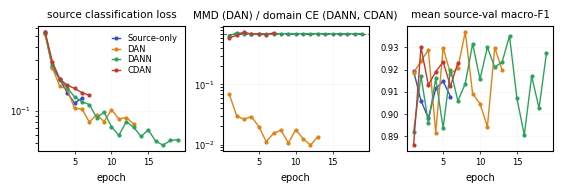

In [14]:
COLORS={"source_only":"#3b4cc0","dan":"#e08214","dann":"#2ca25f","cdan":"#c0392b"}
NAMES={"source_only":"Source-only","dan":"DAN","dann":"DANN","cdan":"CDAN"}
figure,axes=plt.subplots(1,3,figsize=(5.5,1.8))
for method in ["source_only","dan","dann","cdan"]:
    epochs=[entry["epoch"] for entry in HISTORIES[method]]
    axes[0].plot(epochs,[entry["classification_loss"] for entry in HISTORIES[method]],marker="o",markersize=2,lw=1,
                 color=COLORS[method],label=NAMES[method])
    axes[2].plot(epochs,[entry["mean_source_val_macro_f1"] for entry in HISTORIES[method]],marker="o",markersize=2,lw=1,
                 color=COLORS[method],label=NAMES[method])
    if method!="source_only":
        axes[1].plot(epochs,[entry["alignment_loss"] for entry in HISTORIES[method]],marker="o",markersize=2,lw=1,
                     color=COLORS[method],label=NAMES[method])
#ln 2 is the domain loss of a discriminator that cannot tell source from target
axes[1].axhline(math.log(2.0),linestyle="--",lw=0.7,color="0.4")
axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[0].set_title("source classification loss",fontsize=7.5)
axes[1].set_title("MMD (DAN) / domain CE (DANN, CDAN)",fontsize=7.5)
axes[2].set_title("mean source-val macro-F1",fontsize=7.5)
for axis in axes:
    axis.set_xlabel("epoch",fontsize=7)
    axis.tick_params(labelsize=6,length=2,width=0.5)
    axis.grid(alpha=0.15,lw=0.4)
axes[0].legend(frameon=False,fontsize=6,handlelength=1.0,labelspacing=0.2)
figure.tight_layout(pad=0.25,w_pad=0.7)
figure.savefig("task2/results/figures/training_curves.pdf",bbox_inches="tight")
plt.show()


In [15]:
lambda_study={}
for key in STUDY:
    lambda_study[str(key)]=STUDY[key]

epochs_run={}
for method in ["source_only","dan","dann","cdan"]:
    epochs_run[method]=len(HISTORIES[method])

summary={"seed":SEED,"classes":CLASSES,"target_domain":TARGET_DOMAIN,"source_domains":SOURCE_DOMAINS,
         "hyperparameters":{"max_epochs":MAX_EPOCHS,"learning_rate":LEARNING_RATE,"weight_decay":WEIGHT_DECAY,
                            "patience":PATIENCE,"source_batch_per_domain":SOURCE_BATCH_PER_DOMAIN,
                            "target_batch":TARGET_BATCH,"lambda_mmd":1.0,"max_grl_strength":1.0,
                            "grad_clip_norm":1.0,"mmd_estimator":"unbiased",
                            "discriminator_input":"unit_length"},
         "results":RESULTS,"per_class_target_accuracy":per_class,
         "lambda_study":lambda_study,"histories":HISTORIES}
json.dump(summary,open("task2/results/task2_results.json","w"),indent=1)
print("wrote task2/results/task2_results.json")
print("methods:",list(RESULTS.keys()),"| epochs run:",epochs_run)

wrote task2/results/task2_results.json
methods: ['source_only', 'dan', 'dann', 'cdan'] | epochs run: {'source_only': 6, 'dan': 13, 'dann': 19, 'cdan': 7}


In [16]:
from importlib.metadata import version
packages=["torch","torchvision","datasets","scikit-learn","numpy","matplotlib","pyyaml","pillow","tqdm"]
lines=[]
for package in packages:
    lines.append(f"{package}=={version(package).split('+')[0]}")
open("/content/drive/MyDrive/ATML-PA1/task2/requirements.txt","w").write("\n".join(lines)+"\n")
print("\n".join(lines))

torch==2.11.0
torchvision==0.26.0
datasets==4.8.5
scikit-learn==1.6.1
numpy==2.1.3
matplotlib==3.10.0
pyyaml==6.0.3
pillow==11.3.0
tqdm==4.67.3
